In [1]:
# import libraries

import os
import random
import hashlib
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# helper functions for sampling, plotting, and common checks

def get_image_paths(folder_path):
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    return [
        os.path.join(folder_path, filename)
        for filename in os.listdir(folder_path)
        if filename.lower().endswith(".jpg")
    ]


def sample_images(folder_path, sample_count=5):
    image_paths = get_image_paths(folder_path)
    if not image_paths:
        raise ValueError(f"No JPG images found in {folder_path}")
    sample_count = min(sample_count, len(image_paths))
    return random.sample(image_paths, sample_count)


def plot_images(image_paths, title_prefix="", cols=5):
    plt.figure(figsize=(15, 3))
    for index, image_path in enumerate(image_paths, start=1):
        with Image.open(image_path) as img:
            plt.subplot(1, cols, index)
            plt.imshow(img)
            plt.title(f"{title_prefix}{os.path.basename(image_path)}")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

In [3]:
train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")
validation_dir = os.path.join(dataset_root, "validation")

if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Training folder not found: {train_dir}")
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Test folder not found: {test_dir}")

print("Dataset root:", dataset_root)
print("Train directory:", train_dir)
print("Test directory:", test_dir)
if os.path.isdir(validation_dir):
    print("Validation directory:", validation_dir)
else:
    print("Validation directory not found, skipping validation checks.")

NameError: name 'dataset_root' is not defined

Training samples for class angry:


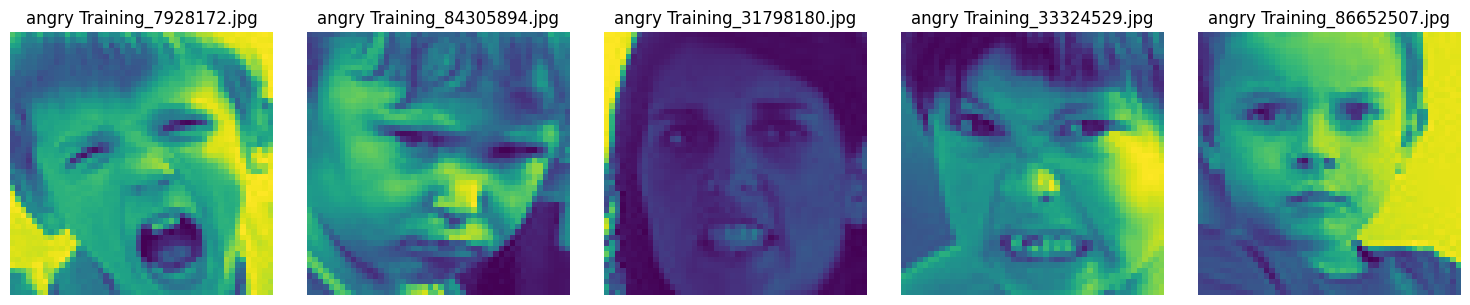

Training samples for class disgust:


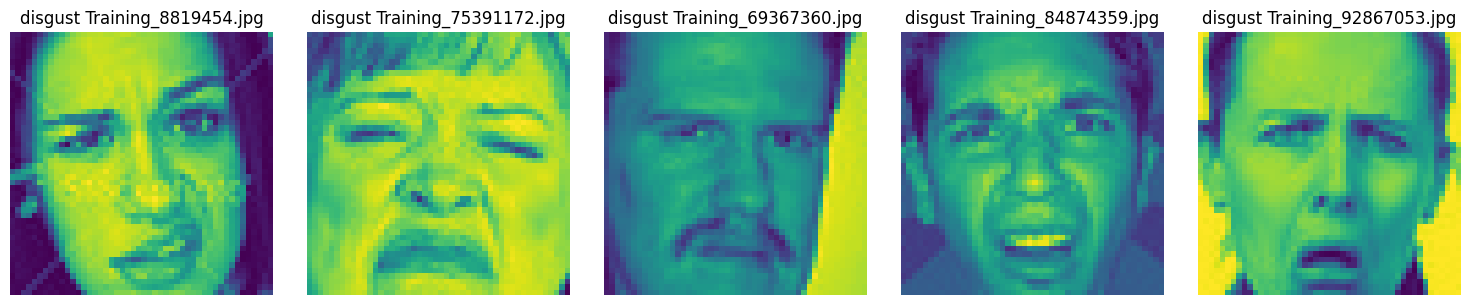

Training samples for class fear:


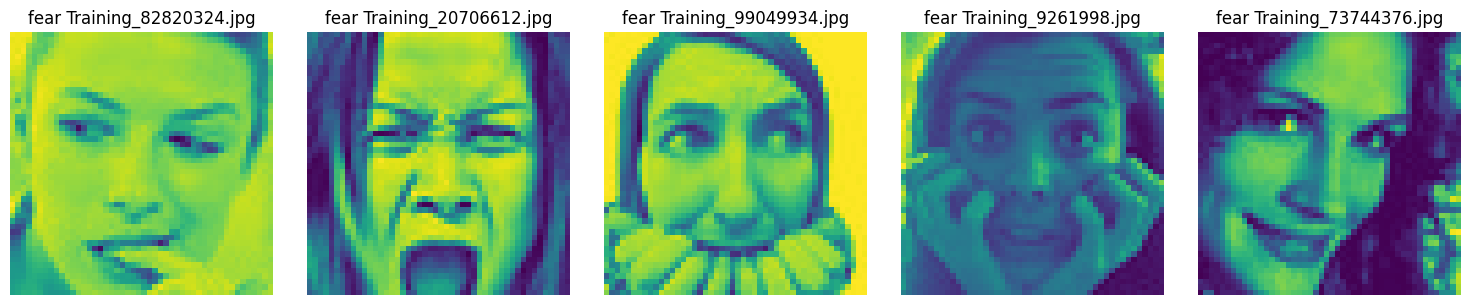

Training samples for class happy:


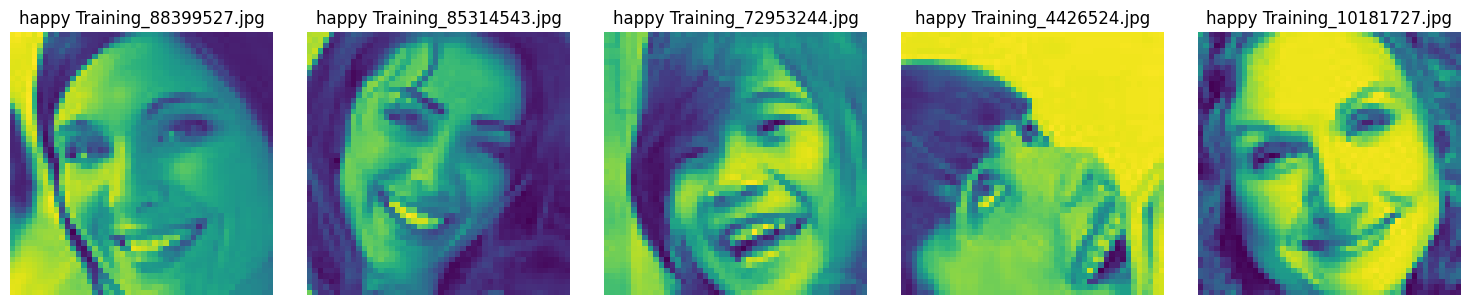

Training samples for class neutral:


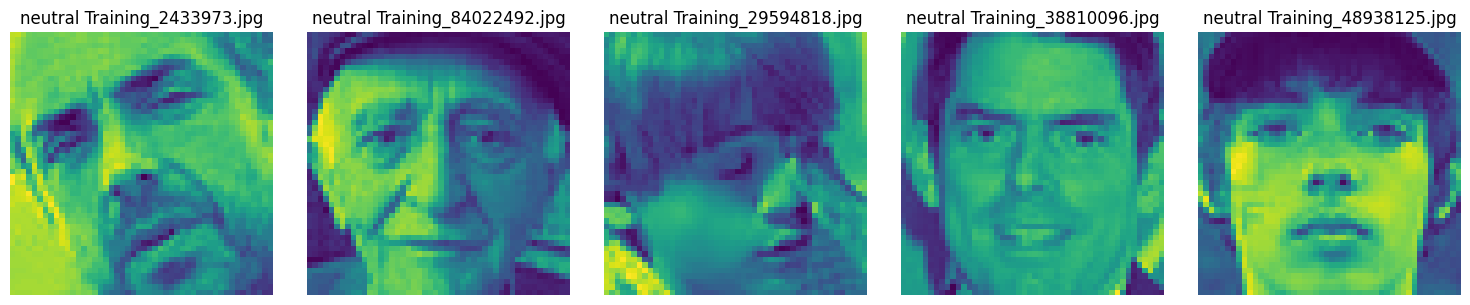

Training samples for class sad:


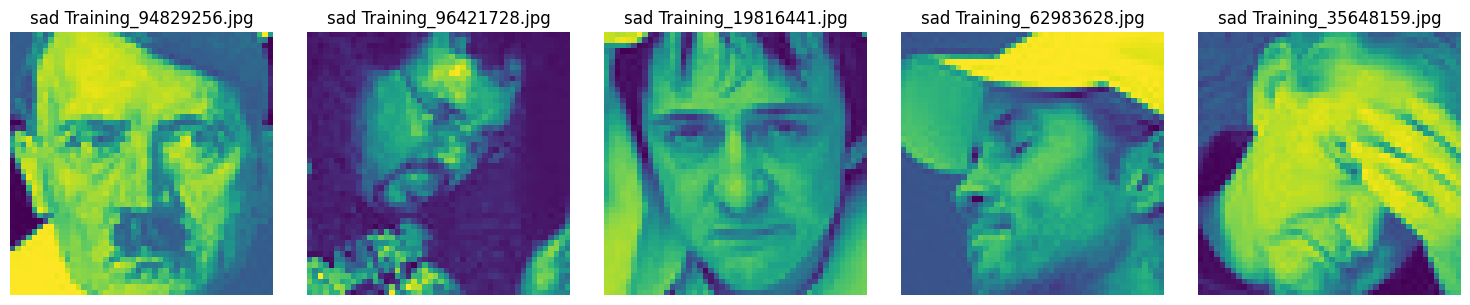

Training samples for class surprise:


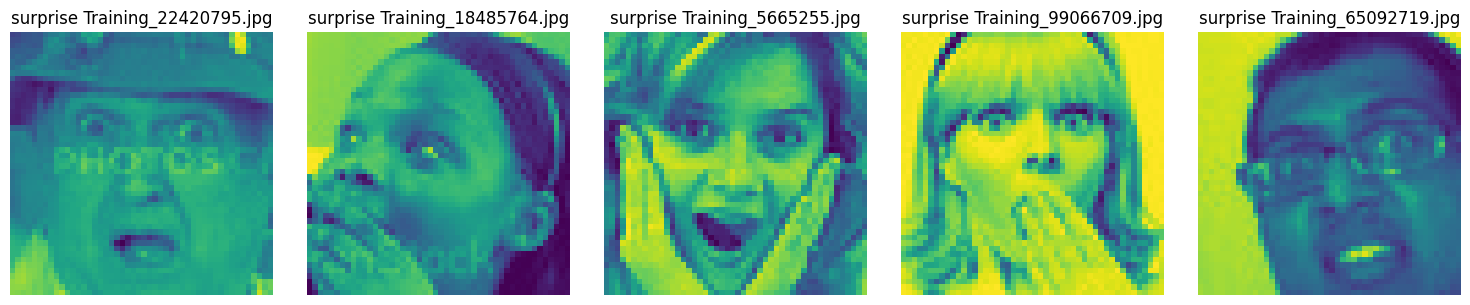

In [ ]:
train_classes = sorted(
    entry for entry in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, entry))
)
for cls in train_classes:
    class_path = os.path.join(train_dir, cls)
    try:
        image_paths = sample_images(class_path, sample_count=5)
    except ValueError as exc:
        print(exc)
        continue
    print(f"Training samples for class {cls}:")
    plot_images(image_paths, title_prefix=f"{cls} ", cols=len(image_paths))

Test samples for class angry:


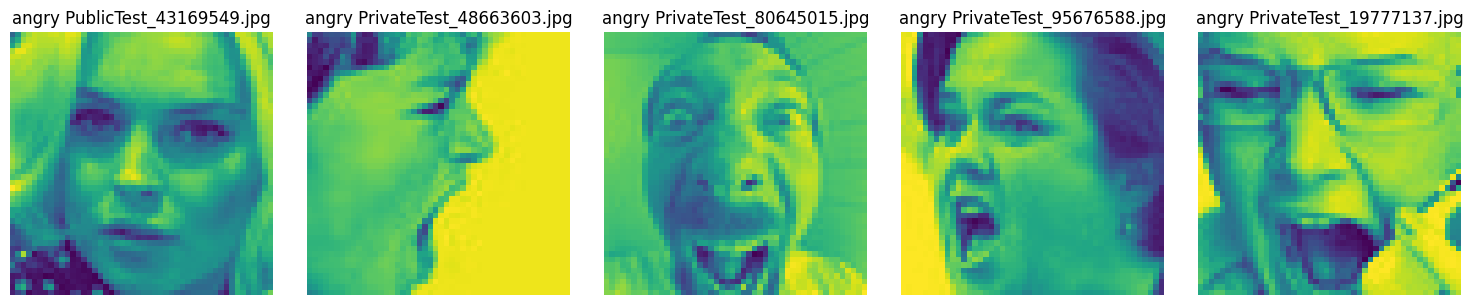

Test samples for class disgust:


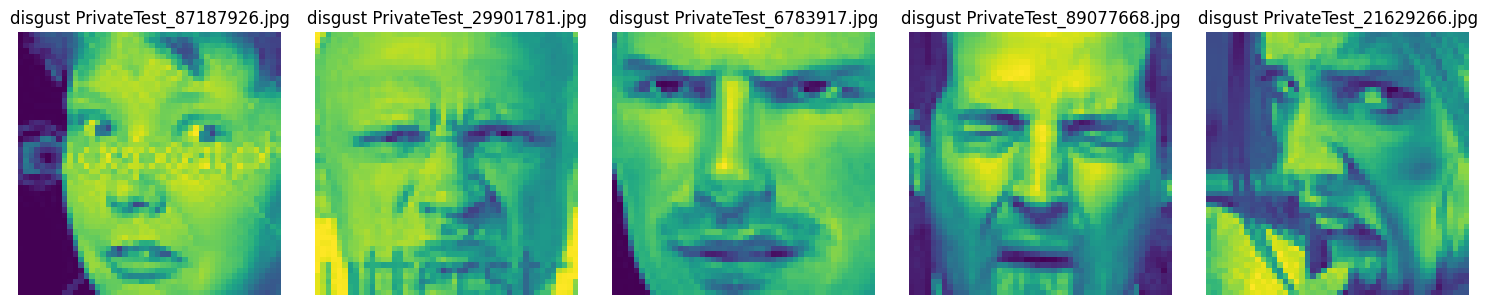

Test samples for class fear:


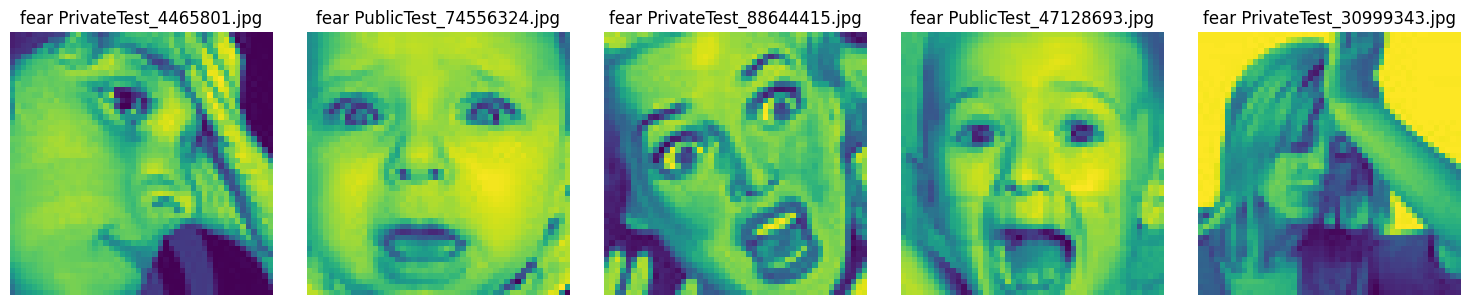

Test samples for class happy:


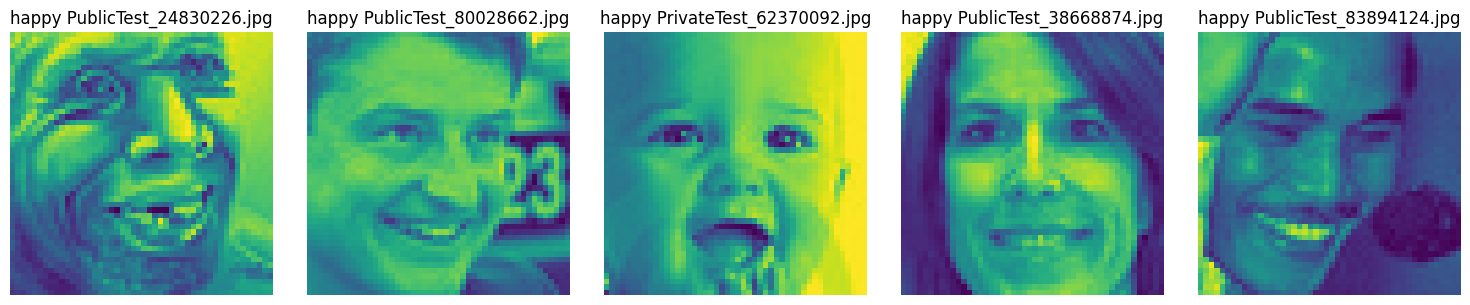

Test samples for class neutral:


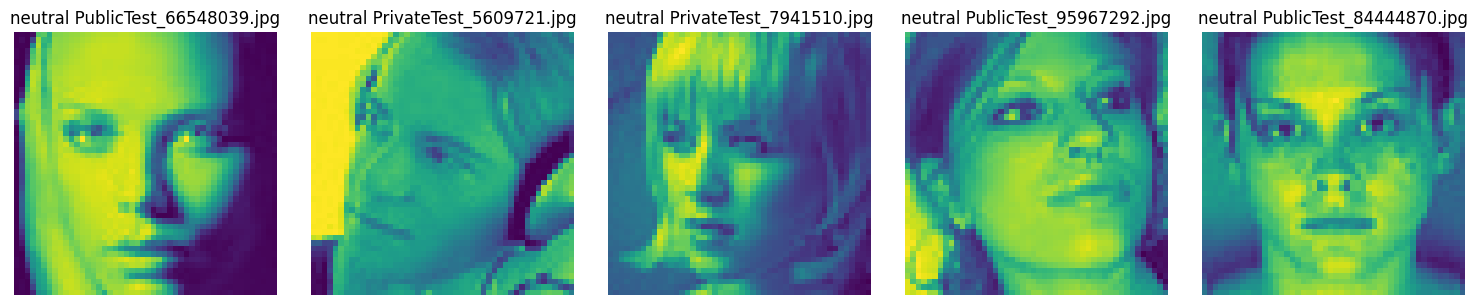

Test samples for class sad:


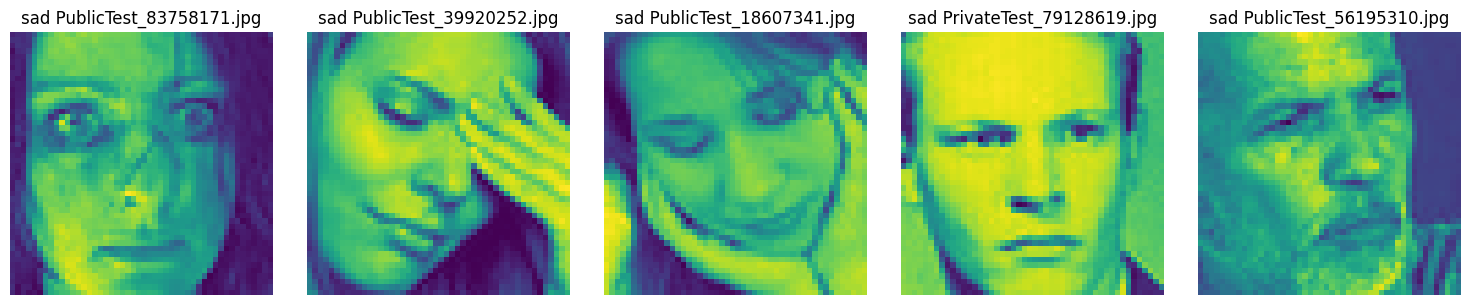

Test samples for class surprise:


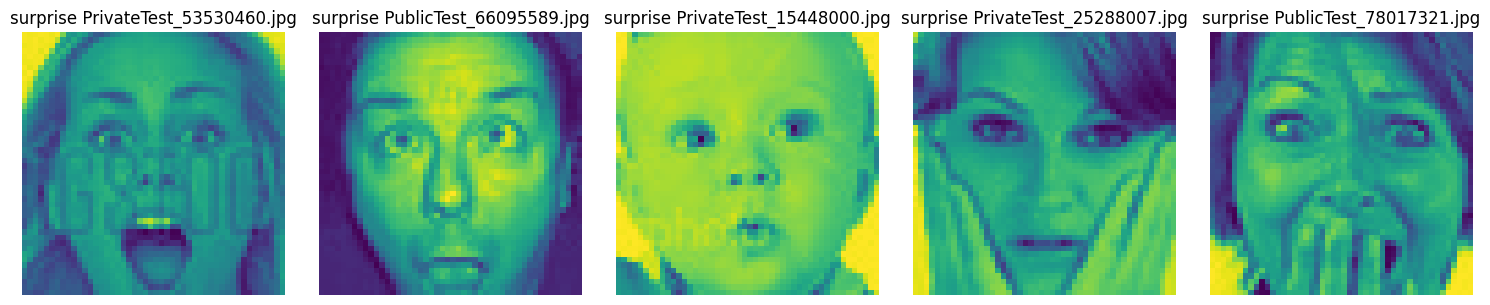

In [ ]:
test_classes = sorted(
    entry for entry in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, entry))
)
for cls in test_classes:
    class_path = os.path.join(test_dir, cls)
    try:
        image_paths = sample_images(class_path, sample_count=5)
    except ValueError as exc:
        print(exc)
        continue
    print(f"Test samples for class {cls}:")
    plot_images(image_paths, title_prefix=f"{cls} ", cols=len(image_paths))

In [ ]:
for label, folder_path in [("train", train_dir), ("test", test_dir)]:
    class_names = sorted(
        entry for entry in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, entry))
    )
    print(f"\n{label.capitalize()} image counts:")
    for cls in class_names:
        class_path = os.path.join(folder_path, cls)
        count = len([name for name in os.listdir(class_path) if name.lower().endswith(".jpg")])
        print(f"  {cls}: {count}")


Train image counts:
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171

Test image counts:
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831


In [ ]:
def get_file_hash(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        hasher.update(f.read())
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.lower().endswith(".jpg"):
                continue
            image_path = os.path.join(root, filename)
            image_hash = get_file_hash(image_path)
            if image_hash in hashes:
                duplicates.append(
                    {
                        "hash": image_hash,
                        "duplicate": image_path,
                        "original": hashes[image_hash],
                    }
                )
            else:
                hashes[image_hash] = image_path
    return duplicates, hashes


duplicates, image_index = find_duplicates(train_dir)
print(f"Found {len(duplicates)} duplicate image files in {train_dir}.")

Found 1236 duplicate image files in C:\Users\omika\.cache\kagglehub\datasets\msambare\fer2013\versions\1\train.


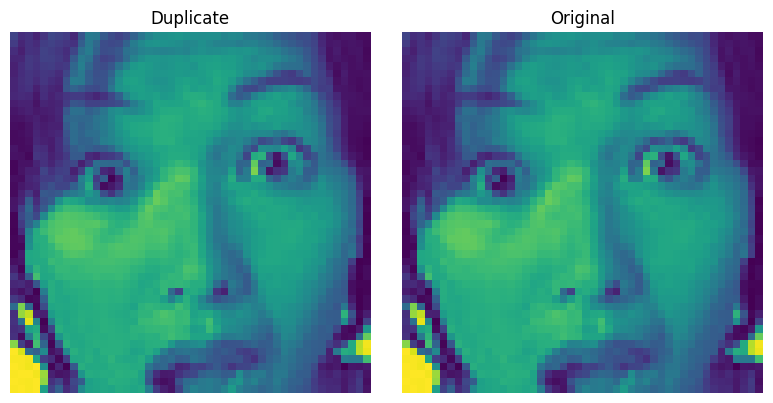

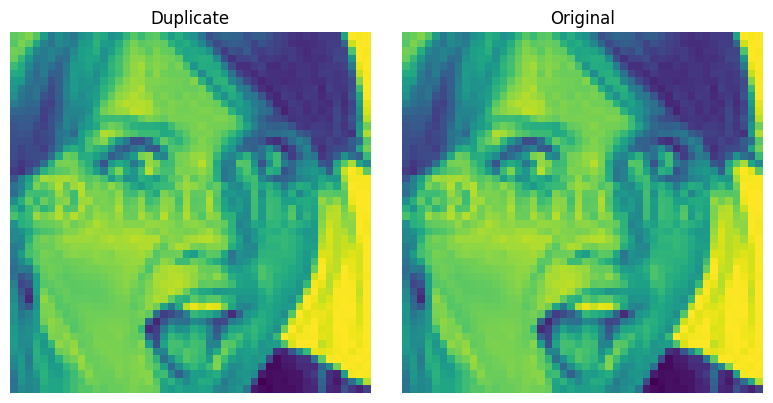

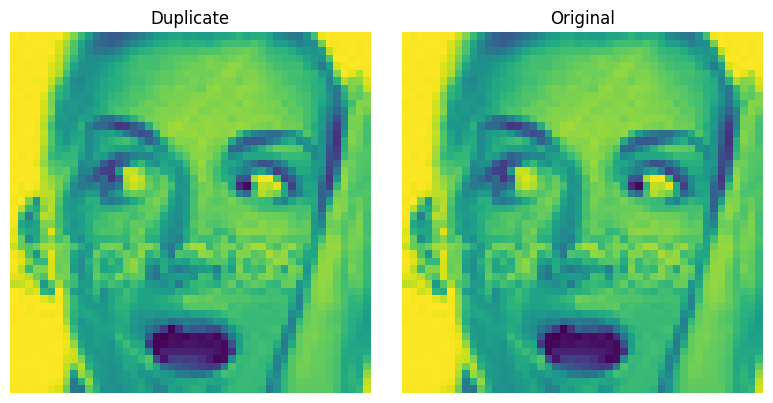

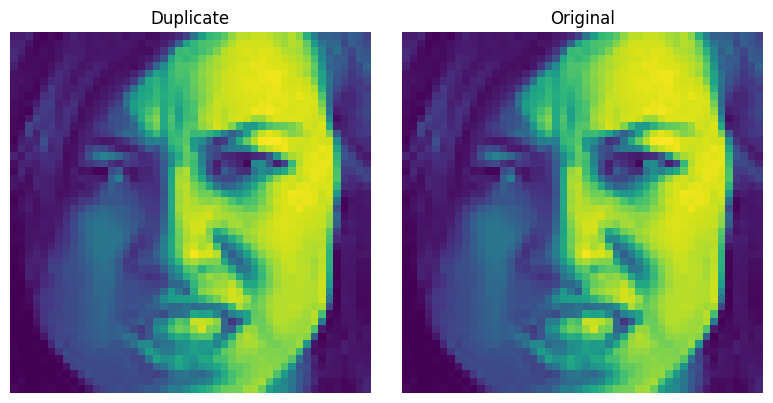

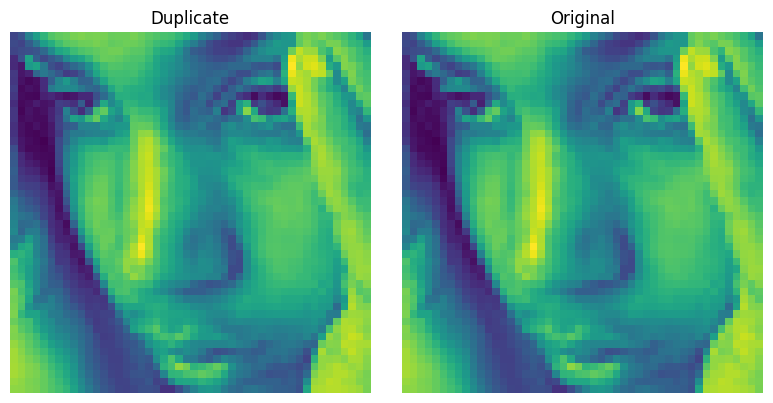

In [ ]:
def plot_duplicate_pairs(duplicate_records, sample_count=5):
    if not duplicate_records:
        print("No duplicate image pairs found in training data.")
        return
    sample_count = min(sample_count, len(duplicate_records))
    for record in random.sample(duplicate_records, sample_count):
        duplicate_path = record["duplicate"]
        original_path = record["original"]
        plt.figure(figsize=(8, 4))
        for idx, path in enumerate([duplicate_path, original_path], start=1):
            with Image.open(path) as img:
                plt.subplot(1, 2, idx)
                plt.imshow(img)
                plt.title("Duplicate" if idx == 1 else "Original")
                plt.axis("off")
        plt.tight_layout()
        plt.show()

plot_duplicate_pairs(duplicates, sample_count=5)

In [ ]:
duplicates_same_class = 0
duplicates_diff_class = 0

for record in duplicates:
    duplicate_class = os.path.basename(os.path.dirname(record["duplicate"]))
    original_class = os.path.basename(os.path.dirname(record["original"]))
    if duplicate_class == original_class:
        duplicates_same_class += 1
    else:
        duplicates_diff_class += 1

print("Duplicates with same label:", duplicates_same_class)
print("Duplicates with different label:", duplicates_diff_class)

Duplicates with same label: 1181
Duplicates with different label: 55


In [ ]:
def verify_images(folder_path):
    corrupt = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.lower().endswith(".jpg"):
                continue
            image_path = os.path.join(root, filename)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception as exc:
                corrupt.append((image_path, str(exc)))
    return corrupt

corrupt_train = verify_images(train_dir)
print("Corrupt images in train:", len(corrupt_train))
for image_path, error in corrupt_train[:10]:
    print(image_path, error)

Corrupt images in train: 0


In [ ]:
def unique_image_extensions(folder_path):
    extensions = set()
    for root, _, files in os.walk(folder_path):
        for filename in files:
            extensions.add(os.path.splitext(filename)[1].lower())
    return sorted(extensions)

print("Train image extensions:", unique_image_extensions(train_dir))
print("Test image extensions:", unique_image_extensions(test_dir))

Train image extensions: ['.jpg']
Test image extensions: ['.jpg']


In [ ]:
def unique_image_sizes(folder_path):
    sizes = set()
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.lower().endswith(".jpg"):
                continue
            with Image.open(os.path.join(root, filename)) as img:
                sizes.add(img.size)
    return sorted(sizes)

print("Unique image pixel dimensions in train:", unique_image_sizes(train_dir))
print("Unique image pixel dimensions in test:", unique_image_sizes(test_dir))

Unique image pixel dimensions in train: [(48, 48)]
Unique image pixel dimensions in test: [(48, 48)]


In [ ]:
def image_file_sizes(folder_path):
    sizes_kb = []
    for root, _, files in os.walk(folder_path):
        for filename in files:
            if not filename.lower().endswith(".jpg"):
                continue
            file_path = os.path.join(root, filename)
            sizes_kb.append(round(os.path.getsize(file_path) / 1024, 2))
    return sizes_kb

train_sizes = image_file_sizes(train_dir)
print("Train image file sizes (KB):", sorted(train_sizes)[:20], "...", len(train_sizes), "files")

Train image file sizes (KB): [0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.35, 0.45, 0.54, 0.55, 0.66, 0.68, 0.71, 0.77, 0.81, 0.82] ... 28709 files


In [ ]:
# 1. duplicates
# 2. duplicates_remove
# 3. corrupt images
# 4. Images extension
# 5. images pixel size
# 6. images file size
